# Embedding Plots and Segment Selection

Load saved embeddings from CAV-MAE and PE-AV runs, then plot similarities and run significance tests.


In [4]:
from pathlib import Path
from typing import List, Tuple, Dict, Any

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# Configure inputs for each model/run.
# Update emb_dir / npz_path and seg_sec to match your extraction outputs.
CAVMAE_RUNS = [
    {
        "label": "cavmae_4s",
        "model_name": "CAV-MAE-Sync",
        "seg_sec": 4.0,
        "emb_dir": Path("/home/amin/Research/Representation/Movie/outputs/7T_MOVIE1_CC1_v2/cav-mae-sync"),
    },
]

PEAV_RUNS = [
    {
        "label": "peav_small_2s",
        "model_name": "PE-AV Small",
        "seg_sec": 2.0,
        "npz_path": Path("/home/amin/Research/Representation/Movie/outputs/7T_MOVIE1_CC1_v2/pe-av-small/peav_small_embeds_2s.npz"),
    },
]

ALPHA = 0.05


In [5]:
def _slugify(text: str) -> str:
    return "".join(ch if ch.isalnum() else "_" for ch in text).strip("_")


def _seg_suffix(seg_sec: float) -> str:
    if seg_sec is None:
        return ""
    if float(seg_sec).is_integer():
        return f"{int(seg_sec)}s"
    return f"{seg_sec:g}s"


def _print_stats(name: str, arr: np.ndarray):
    arr_min = float(np.min(arr))
    arr_max = float(np.max(arr))
    arr_mean = float(np.mean(arr))
    arr_std = float(np.std(arr))
    print(f"{name}: shape={arr.shape} min={arr_min:.4g} max={arr_max:.4g} mean={arr_mean:.4g} std={arr_std:.4g}")
    if arr.ndim >= 2:
        norms = np.linalg.norm(arr, axis=1)
        zero_frac = float(np.mean(norms < 1e-6))
        print(
            f"{name} row-norms: min={norms.min():.4g} mean={norms.mean():.4g} max={norms.max():.4g}"
            f" zero_frac={zero_frac:.3f}"
        )


def _auto_vmin_vmax(sim: np.ndarray, pct: float = 2.0):
    flat = sim.ravel()
    vmin = float(np.percentile(flat, pct))
    vmax = float(np.percentile(flat, 100.0 - pct))
    if vmin == vmax:
        eps = 1e-6 if vmin == 0 else abs(vmin) * 0.05
        vmin -= eps
        vmax += eps
    return vmin, vmax


def load_embeddings_dir(emb_dir: Path) -> Tuple[np.ndarray, np.ndarray]:
    """Load audio and video embeddings saved by extract_embeddings_for_video."""
    emb_dir = emb_dir.expanduser().resolve()
    audio_path = emb_dir / "embeddings_audio.npy"
    video_path = emb_dir / "embeddings_video.npy"
    if not audio_path.exists() or not video_path.exists():
        raise FileNotFoundError(
            f"Missing embeddings: expected {audio_path} and {video_path}. "
            "Run embedding extraction first."
        )
    audio = np.load(audio_path)
    video = np.load(video_path)
    if audio.shape[0] != video.shape[0]:
        raise ValueError(
            f"Segment count mismatch: audio={audio.shape[0]} video={video.shape[0]}"
        )
    return audio, video


def load_embeddings_npz(npz_path: Path) -> Tuple[np.ndarray, np.ndarray]:
    """Load audio and video embeddings saved by the PE-AV extractor."""
    npz_path = npz_path.expanduser().resolve()
    if not npz_path.exists():
        raise FileNotFoundError(
            f"Missing embeddings: expected {npz_path}. Run embedding extraction first."
        )
    data = np.load(npz_path)
    if "audio" not in data or "video" not in data:
        raise KeyError("NPZ must contain 'audio' and 'video' arrays")
    audio = data["audio"]
    video = data["video"]
    if audio.shape[0] != video.shape[0]:
        raise ValueError(
            f"Segment count mismatch: audio={audio.shape[0]} video={video.shape[0]}"
        )
    return audio, video


def cosine_matrix(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    """Cosine similarity between rows of a and b."""
    a_norm = a / np.linalg.norm(a, axis=1, keepdims=True).clip(min=1e-9)
    b_norm = b / np.linalg.norm(b, axis=1, keepdims=True).clip(min=1e-9)
    return a_norm @ b_norm.T


def compute_rdm(embeddings: np.ndarray) -> np.ndarray:
    """Pairwise cosine-distance RDM for segment embeddings."""
    normed = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True).clip(min=1e-9)
    cos_sim = normed @ normed.T
    return 1.0 - cos_sim


def plot_heatmap(sim: np.ndarray, out_path: Path, title: str, vmin: float, vmax: float):
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(sim, origin="upper", cmap="coolwarm", vmin=vmin, vmax=vmax)
    fig.colorbar(im, fraction=0.046, pad=0.04, label="Cosine similarity")
    ax.set_xlabel("Video segment index")
    ax.set_ylabel("Audio segment index")
    ax.set_title(title)
    fig.tight_layout()
    fig.savefig(out_path, dpi=300)
    plt.show()
    plt.close(fig)


def compute_diag_stats(sim: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Return diagonal, off-diagonal mean, std, and standard error per row."""
    diag = np.diag(sim)
    if sim.shape[0] > 1:
        n_off = sim.shape[1] - 1
        off_sum = sim.sum(axis=1) - diag
        off_mean = off_sum / n_off
        off_var = ((sim - diag[:, None]) ** 2).sum(axis=1) / n_off
        off_std = np.sqrt(off_var)
        off_se = off_std / np.sqrt(n_off)
    else:
        off_mean = np.zeros_like(diag)
        off_std = np.zeros_like(diag)
        off_se = np.zeros_like(diag)
    return diag, off_mean, off_std, off_se


def plot_diag_stats(
    diag: np.ndarray,
    off_mean: np.ndarray,
    off_std: np.ndarray,
    off_se: np.ndarray,
    out_path: Path,
    title: str,
):
    x = np.arange(diag.shape[0])
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(x, diag, label="diag (vid<->aud)", color="C0")
    ax.plot(x, off_mean, label="off-diag mean", color="C1")
    ax.fill_between(
        x,
        off_mean - off_se,
        off_mean + off_se,
        color="C1",
        alpha=0.3,
        label="off-diag +/-1 se",
    )
    ax.set_xlabel("Segment index")
    ax.set_ylabel("Similarity")
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    fig.savefig(out_path, dpi=300)
    plt.show()
    plt.close(fig)


def plot_diag_stats_flagged(
    diag: np.ndarray,
    off_mean: np.ndarray,
    off_std: np.ndarray,
    off_se: np.ndarray,
    sig_indices: List[int],
    out_path: Path,
    title: str,
):
    """Same as plot_diag_stats but marks significant segments with stars."""
    x = np.arange(diag.shape[0])
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(
        x,
        diag,
        label="diag (vid<->aud)",
        color="C0",
        marker="o",
        markersize=4,
        linewidth=1.5,
    )
    ax.plot(x, off_mean, label="off-diag mean", color="C1")
    ax.fill_between(
        x,
        off_mean - off_se,
        off_mean + off_se,
        color="C1",
        alpha=0.3,
        label="off-diag +/-1 se",
    )
    if sig_indices:
        ax.scatter(
            sig_indices,
            diag[sig_indices],
            marker="*",
            facecolor="black",
            edgecolor="k",
            s=100,
            zorder=3,
            label="significant (diag > off-diag, p<alpha)",
        )
    ax.set_xlabel("Segment index")
    ax.set_ylabel("Similarity")
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    fig.savefig(out_path, dpi=300)
    plt.show()
    plt.close(fig)


def one_sided_ttest(off_vals: np.ndarray, diag_val: float) -> float:
    """One-sided t-test: H1 mean(off_vals) < diag_val. Returns p-value."""
    try:
        res = stats.ttest_1samp(off_vals, popmean=diag_val, alternative="less")
        return float(res.pvalue)
    except TypeError:
        res = stats.ttest_1samp(off_vals, popmean=diag_val)
        if np.isnan(res.statistic):
            return np.nan
        if res.statistic < 0:
            return float(res.pvalue / 2.0)
        return float(1.0 - res.pvalue / 2.0)


def find_significant(sim: np.ndarray, alpha: float) -> List[int]:
    """Return indices where diag > off-diagonal with one-sided t-test at alpha."""
    if sim.shape[0] != sim.shape[1]:
        raise ValueError(f"Similarity matrix must be square; got {sim.shape}")
    n = sim.shape[0]
    if n < 2:
        return []
    diag = np.diag(sim)
    sig_indices: List[int] = []
    for i in range(n):
        off = np.concatenate([sim[i, :i], sim[i, i + 1 :]])
        if off.size == 0:
            continue
        p = one_sided_ttest(off, diag[i])
        if np.isnan(p):
            continue
        if p < alpha and diag[i] > off.mean():
            sig_indices.append(i)
    return sig_indices


def run_segment_selection(
    audio: np.ndarray,
    video: np.ndarray,
    out_dir: Path,
    label: str,
    model_name: str,
    seg_sec: float,
    alpha: float,
):
    out_dir = out_dir.expanduser().resolve()
    out_dir.mkdir(parents=True, exist_ok=True)

    _print_stats(f"{label} audio", audio)
    _print_stats(f"{label} video", video)

    sim = cosine_matrix(audio, video)
    _print_stats(f"{label} sim", sim)

    seg_suffix = _seg_suffix(seg_sec)
    label_slug = _slugify(label)
    title_suffix = f" ({seg_suffix} segments)" if seg_suffix else ""
    title_base = f"{model_name}{title_suffix}"

    sim_path = out_dir / f"{label_slug}_av_similarity_matrix.npy"
    np.save(sim_path, sim.astype(np.float32))

    rdm_audio = compute_rdm(audio)
    rdm_video = compute_rdm(video)
    rdm_audio_path = out_dir / f"{label_slug}_rdm_audio_cosine.npy"
    rdm_video_path = out_dir / f"{label_slug}_rdm_video_cosine.npy"
    np.save(rdm_audio_path, rdm_audio.astype(np.float32))
    np.save(rdm_video_path, rdm_video.astype(np.float32))

    heatmap_fixed_path = out_dir / f"{label_slug}_av_similarity_heatmap_fixed.png"
    heatmap_auto_path = out_dir / f"{label_slug}_av_similarity_heatmap_auto.png"
    diag_plot_path = out_dir / f"{label_slug}_diag_offdiag.png"
    diag_flagged_path = out_dir / f"{label_slug}_diag_offdiag_flagged.png"

    plot_heatmap(
        sim,
        heatmap_fixed_path,
        title=f"{title_base} A/V Cosine Similarity (fixed -1..1)",
        vmin=-1.0,
        vmax=1.0,
    )

    auto_vmin, auto_vmax = _auto_vmin_vmax(sim)
    plot_heatmap(
        sim,
        heatmap_auto_path,
        title=f"{title_base} A/V Cosine Similarity (auto scale)",
        vmin=auto_vmin,
        vmax=auto_vmax,
    )

    diag, off_mean, off_std, off_se = compute_diag_stats(sim)
    plot_diag_stats(
        diag,
        off_mean,
        off_std,
        off_se,
        diag_plot_path,
        title=f"{title_base} Diagonal vs. Off-diagonal Similarity",
    )

    sig_indices = find_significant(sim, alpha)
    plot_diag_stats_flagged(
        diag,
        off_mean,
        off_std,
        off_se,
        sig_indices,
        diag_flagged_path,
        title=f"{title_base} Diagonal vs. Off-diagonal (flagged)",
    )

    out_npy = out_dir / f"{label_slug}_significant_segments.npy"
    out_txt = out_dir / f"{label_slug}_significant_segments.txt"
    np.save(out_npy, np.array(sig_indices, dtype=np.int64))
    with open(out_txt, "w") as f:
        f.write("# Segment indices (0-based) with diag > off-diag, p < {:.3f}".format(alpha))
        f.write(",".join(str(idx) for idx in sig_indices))

    print(f"Saved similarity matrix to {sim_path} with shape {sim.shape}")
    print(f"Saved audio RDM to {rdm_audio_path}")
    print(f"Saved video RDM to {rdm_video_path}")
    print(f"Saved fixed heatmap to {heatmap_fixed_path}")
    print(f"Saved auto heatmap to {heatmap_auto_path}")
    print(f"Saved diagonal/off-diagonal plot to {diag_plot_path}")
    print(f"Saved significance-flagged plot to {diag_flagged_path}")
    print(f"Found {len(sig_indices)} significant segments (alpha={alpha}); saved to {out_npy} and {out_txt}")


cavmae_4s audio: shape=(231, 768) min=-3.17 max=2.756 mean=-0.0003381 std=0.4937
cavmae_4s audio row-norms: min=11.95 mean=13.65 max=17.49 zero_frac=0.000
cavmae_4s video: shape=(231, 768) min=-3.927 max=5.644 mean=0.007785 std=0.5633
cavmae_4s video row-norms: min=11.3 mean=15.5 max=18.78 zero_frac=0.000
cavmae_4s sim: shape=(231, 231) min=-0.08766 max=0.4582 mean=0.1844 std=0.07172
cavmae_4s sim row-norms: min=1.734 mean=2.975 max=4.204 zero_frac=0.000


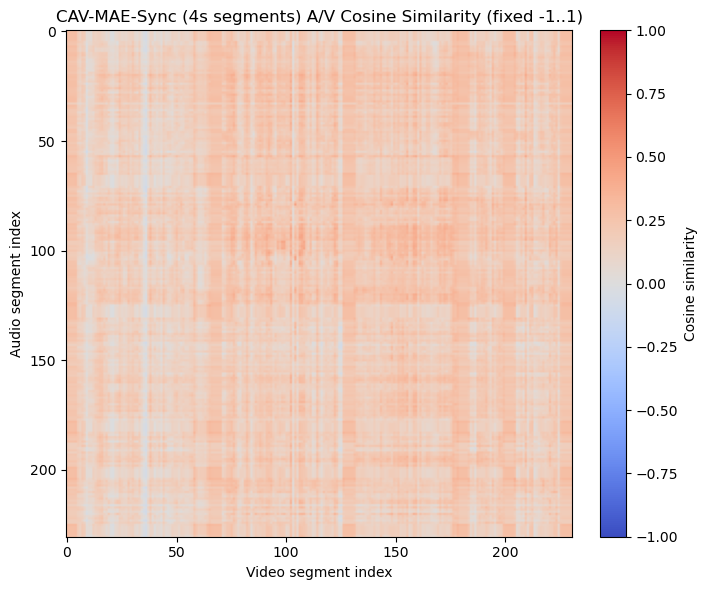

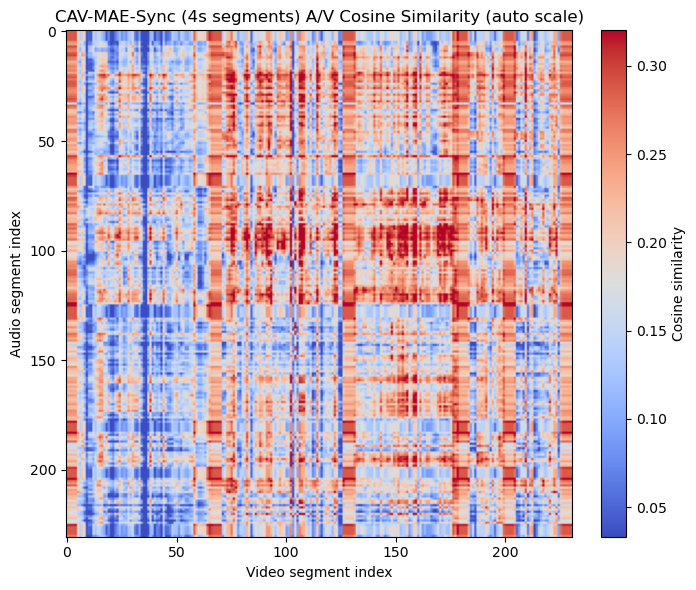

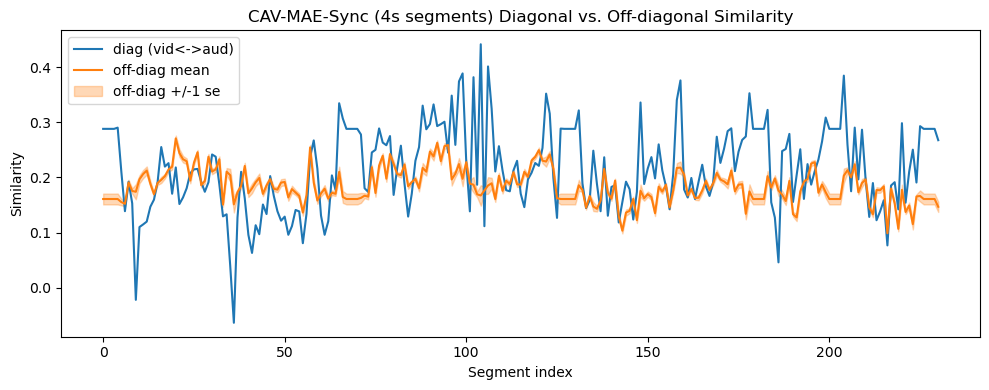

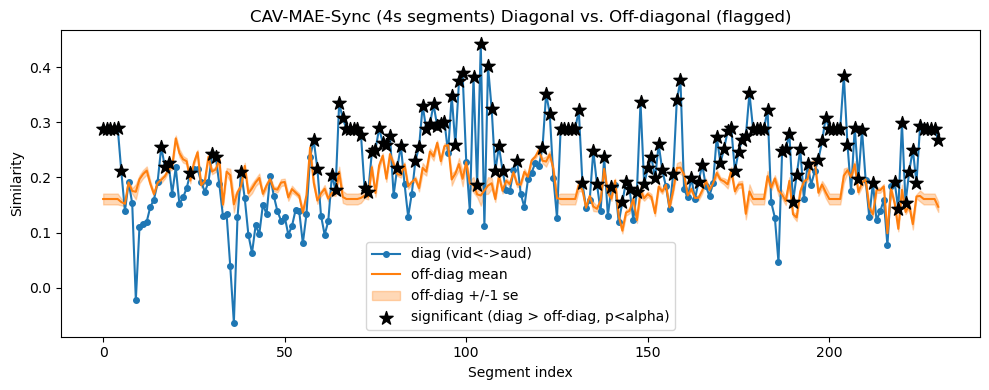

Saved similarity matrix to /home/amin/Research/Representation/Movie/outputs/7T_MOVIE1_CC1_v2/cav-mae-sync/cavmae_4s_av_similarity_matrix.npy with shape (231, 231)
Saved audio RDM to /home/amin/Research/Representation/Movie/outputs/7T_MOVIE1_CC1_v2/cav-mae-sync/cavmae_4s_rdm_audio_cosine.npy
Saved video RDM to /home/amin/Research/Representation/Movie/outputs/7T_MOVIE1_CC1_v2/cav-mae-sync/cavmae_4s_rdm_video_cosine.npy
Saved fixed heatmap to /home/amin/Research/Representation/Movie/outputs/7T_MOVIE1_CC1_v2/cav-mae-sync/cavmae_4s_av_similarity_heatmap_fixed.png
Saved auto heatmap to /home/amin/Research/Representation/Movie/outputs/7T_MOVIE1_CC1_v2/cav-mae-sync/cavmae_4s_av_similarity_heatmap_auto.png
Saved diagonal/off-diagonal plot to /home/amin/Research/Representation/Movie/outputs/7T_MOVIE1_CC1_v2/cav-mae-sync/cavmae_4s_diag_offdiag.png
Saved significance-flagged plot to /home/amin/Research/Representation/Movie/outputs/7T_MOVIE1_CC1_v2/cav-mae-sync/cavmae_4s_diag_offdiag_flagged.png
Fo

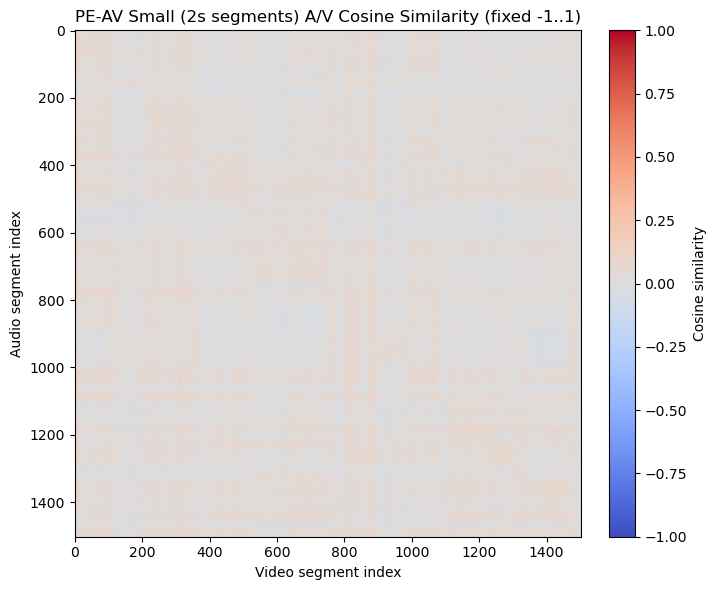

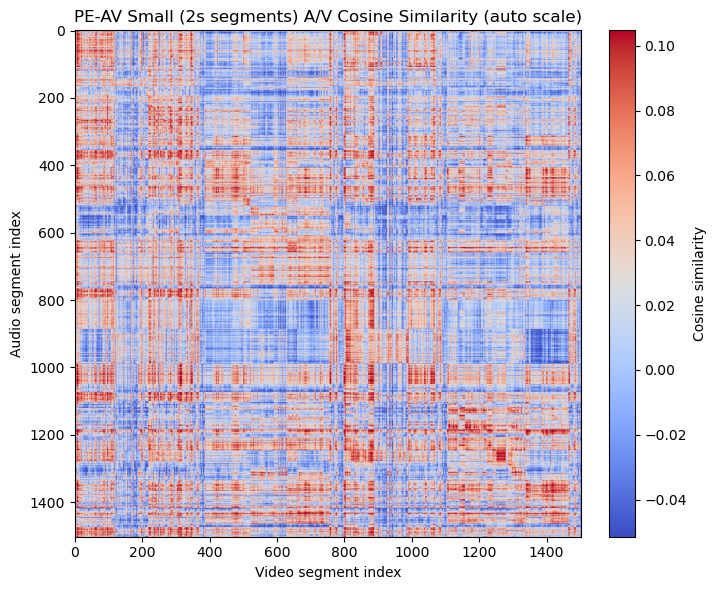

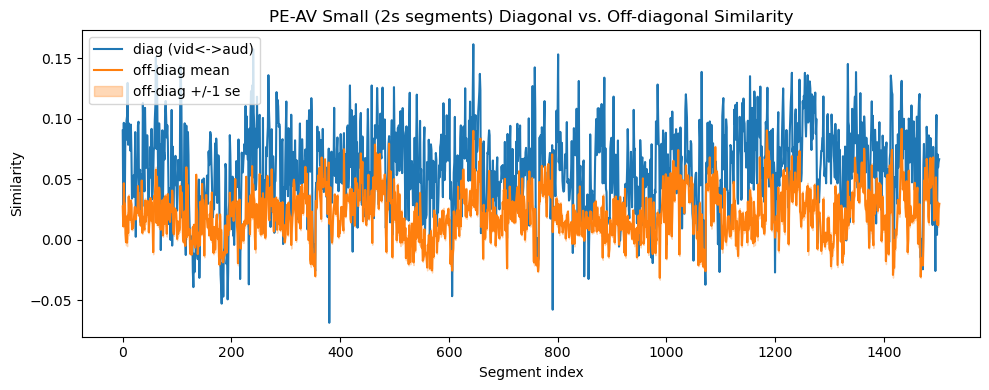

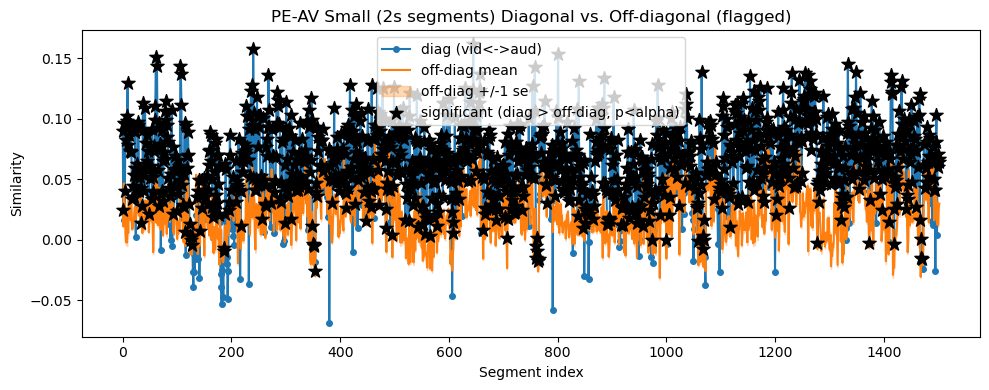

Saved similarity matrix to /home/amin/Research/Representation/Movie/outputs/7T_MOVIE1_CC1_v2/pe-av-small/peav_small_2s_av_similarity_matrix.npy with shape (1503, 1503)
Saved audio RDM to /home/amin/Research/Representation/Movie/outputs/7T_MOVIE1_CC1_v2/pe-av-small/peav_small_2s_rdm_audio_cosine.npy
Saved video RDM to /home/amin/Research/Representation/Movie/outputs/7T_MOVIE1_CC1_v2/pe-av-small/peav_small_2s_rdm_video_cosine.npy
Saved fixed heatmap to /home/amin/Research/Representation/Movie/outputs/7T_MOVIE1_CC1_v2/pe-av-small/peav_small_2s_av_similarity_heatmap_fixed.png
Saved auto heatmap to /home/amin/Research/Representation/Movie/outputs/7T_MOVIE1_CC1_v2/pe-av-small/peav_small_2s_av_similarity_heatmap_auto.png
Saved diagonal/off-diagonal plot to /home/amin/Research/Representation/Movie/outputs/7T_MOVIE1_CC1_v2/pe-av-small/peav_small_2s_diag_offdiag.png
Saved significance-flagged plot to /home/amin/Research/Representation/Movie/outputs/7T_MOVIE1_CC1_v2/pe-av-small/peav_small_2s_diag

In [6]:
# CAV-MAE runs
for run in CAVMAE_RUNS:
    emb_dir = Path(run["emb_dir"])
    audio, video = load_embeddings_dir(emb_dir)
    out_dir = emb_dir
    run_segment_selection(
        audio=audio,
        video=video,
        out_dir=out_dir,
        label=run["label"],
        model_name=run["model_name"],
        seg_sec=run["seg_sec"],
        alpha=ALPHA,
    )

# PE-AV runs
for run in PEAV_RUNS:
    npz_path = Path(run["npz_path"])
    audio, video = load_embeddings_npz(npz_path)
    out_dir = npz_path.parent
    run_segment_selection(
        audio=audio,
        video=video,
        out_dir=out_dir,
        label=run["label"],
        model_name=run["model_name"],
        seg_sec=run["seg_sec"],
        alpha=ALPHA,
    )
